# Used Car Price Prediction: A Regression Project

## 1. Project Overview & Dataset Description
The goal of this project is to build a machine learning regression model capable of predicting the fair market price of used cars based on their specifications.

### Dataset Details
* **Dataset Name:** Used Cars Pricing Dataset (`used_cars.csv`)
* **Dataset Source:** Kaggle - Vehicle Sales Data
* **Number of Observations (Rows):** 4,009 rows (Satisfies the >500 observations requirement)
* **Number of Features (Columns):** 12 columns (Satisfies the >5 features requirement)
* **Target Variable:** `price` (Continuous numerical value)

### Feature Descriptions (Data Dictionary)
The dataset consists of the following columns:

**Numerical Features:**
* `model_year` (int64): The manufacturing year of the vehicle.
* `milage` (object - needs conversion): The total distance the car has traveled (e.g., "51,000 mi."). *Requires preprocessing to extract numerical values.*
* `price` (object - target variable): The listed price of the car (e.g., "$10,300"). *Requires preprocessing to extract numerical values.*

**Categorical Features:**
* `brand` (object): The manufacturer or make of the car (e.g., Ford, Audi).
* `model` (object): The specific model of the car.
* `fuel_type` (object): The type of fuel the vehicle consumes (e.g., Gasoline, Hybrid). *(Contains 170 missing values).*
* `engine` (object): Engine specifications including horsepower and displacement.
* `transmission` (object): The type of gear transmission (e.g., Automatic, Manual).
* `ext_col` (object): The exterior color of the car.
* `int_col` (object): The interior color of the car.
* `accident` (object): Indicates if the car has a reported accident history. *(Contains 113 missing values).*
* `clean_title` (object): Indicates if the car has a clean legal title. *(Contains 596 missing values).*

In [2]:
import pandas as pd
file_path = r"C:\Users\AdOOl\Downloads\used_cars.csv"
df = pd.read_csv(file_path)
df['price'] = df['price'].astype(str).str.replace(r'[^0-9.]', '', regex=True).astype(float)
df['milage'] = df['milage'].astype(str).str.replace(r'[^0-9.]', '', regex=True).astype(float)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
print("Numerical Columns:")
print(numerical_cols)
print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['model_year', 'milage', 'price']

Categorical Columns:
['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']


## 2. Discovering Missing Values

Before performing any analysis or feeding data to machine learning models, it is crucial to identify if our dataset contains any missing information (NaN/Null values). Missing data can cause machine learning algorithms to fail or produce biased results. 

In this step, we will use the `isnull().sum()` function to count the exact number of missing entries in each column to determine the scale of the problem.

In [3]:
missing_values = df.isnull().sum()
missing_columns = missing_values[missing_values > 0]

print("Columns with missing values and their counts:")
print(missing_columns)

Columns with missing values and their counts:
fuel_type      170
accident       113
clean_title    596
dtype: int64


## 3. Handling Missing Values (Data Imputation)

Based on the previous step, we identified missing values in three specific columns: `fuel_type`, `accident`, and `clean_title`. 

**Handling Strategy & Justification:**
It is important to note that all three of these columns represent **Categorical Variables** (text-based classes), not numerical continuous data. Therefore, mathematical imputation techniques like the Mean or Median are statistically invalid here.

We are left with two primary approaches:
1. **Listwise Deletion (Dropping Rows):** Deleting any row that contains a missing value. 
2. **Mode Imputation:** Replacing the missing value with the most frequent category (the Mode) in that specific column.

**Our Decision: Mode Imputation**
I chose to handle the missing values using **Mode Imputation** rather than dropping the rows. 
*   **Why?** The `clean_title` column alone has nearly 600 missing values. If we chose to drop rows, we would lose roughly 15% of our entire dataset. In statistics and machine learning, retaining dataset size (preserving degrees of freedom and statistical power) is highly prioritized. Replacing these categorical NaNs with the Mode is a standard, robust statistical practice that preserves the dataset's volume without significantly distorting the underlying distribution of the classes.

In [4]:
df['fuel_type'] = df['fuel_type'].fillna(df['fuel_type'].mode()[0])
df['accident'] = df['accident'].fillna(df['accident'].mode()[0])
df['clean_title'] = df['clean_title'].fillna(df['clean_title'].mode()[0])
print("Total missing values after imputation:")
print(df.isnull().sum().sum())

Total missing values after imputation:
0


### 4. Detecting Potential Outliers

As required by the project guidelines, we must detect potential outliers in our numerical data before moving forward. 
We will use the standard **Interquartile Range (IQR)** method to identify outliers in our key numerical columns: `price` and `milage`.

**Handling Strategy & Justification:**
In the context of the used car market, high prices often represent valid data points (e.g., luxury, classic, or sports cars), and exceptionally high milage represents heavily used but still valid vehicles. Therefore, we will *detect* and count these outliers to understand our data distribution, but we will **not remove them**. Removing them would artificially truncate our dataset and cause our model to fail when predicting prices for luxury or highly-used cars in the real world.

In [5]:
def count_outliers(column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)].shape[0]
    return outliers_count

price_outliers = count_outliers('price')
milage_outliers = count_outliers('milage')

print(f"Potential outliers detected in 'price': {price_outliers} cars")
print(f"Potential outliers detected in 'milage': {milage_outliers} cars")
print("Action: Kept in the dataset to preserve market variance.")

Potential outliers detected in 'price': 244 cars
Potential outliers detected in 'milage': 69 cars
Action: Kept in the dataset to preserve market variance.


## 5. Exploratory Data Analysis (EDA)

The goal of EDA is to discover patterns, spot anomalies, and understand the relationship between our features and the target variable (`price`). Although the project requires at least 3 visualizations, we will perform a more comprehensive analysis using 5 distinct plots to gain deeper insights into the used car market:

1.  **Target Variable Distribution (Histplot):** To understand how car prices are spread out.
2.  **Numerical Relationship 1 (Scatterplot):** To see how `milage` impacts `price`.
3.  **Numerical Relationship 2 (Scatterplot):** To see how `model_year` impacts `price`.
4.  **Categorical Relationship (Boxplot):** To analyze the effect of `accident` history on `price`.
5.  **Correlation Matrix (Heatmap):** To statistically measure the linear relationships between numerical features.

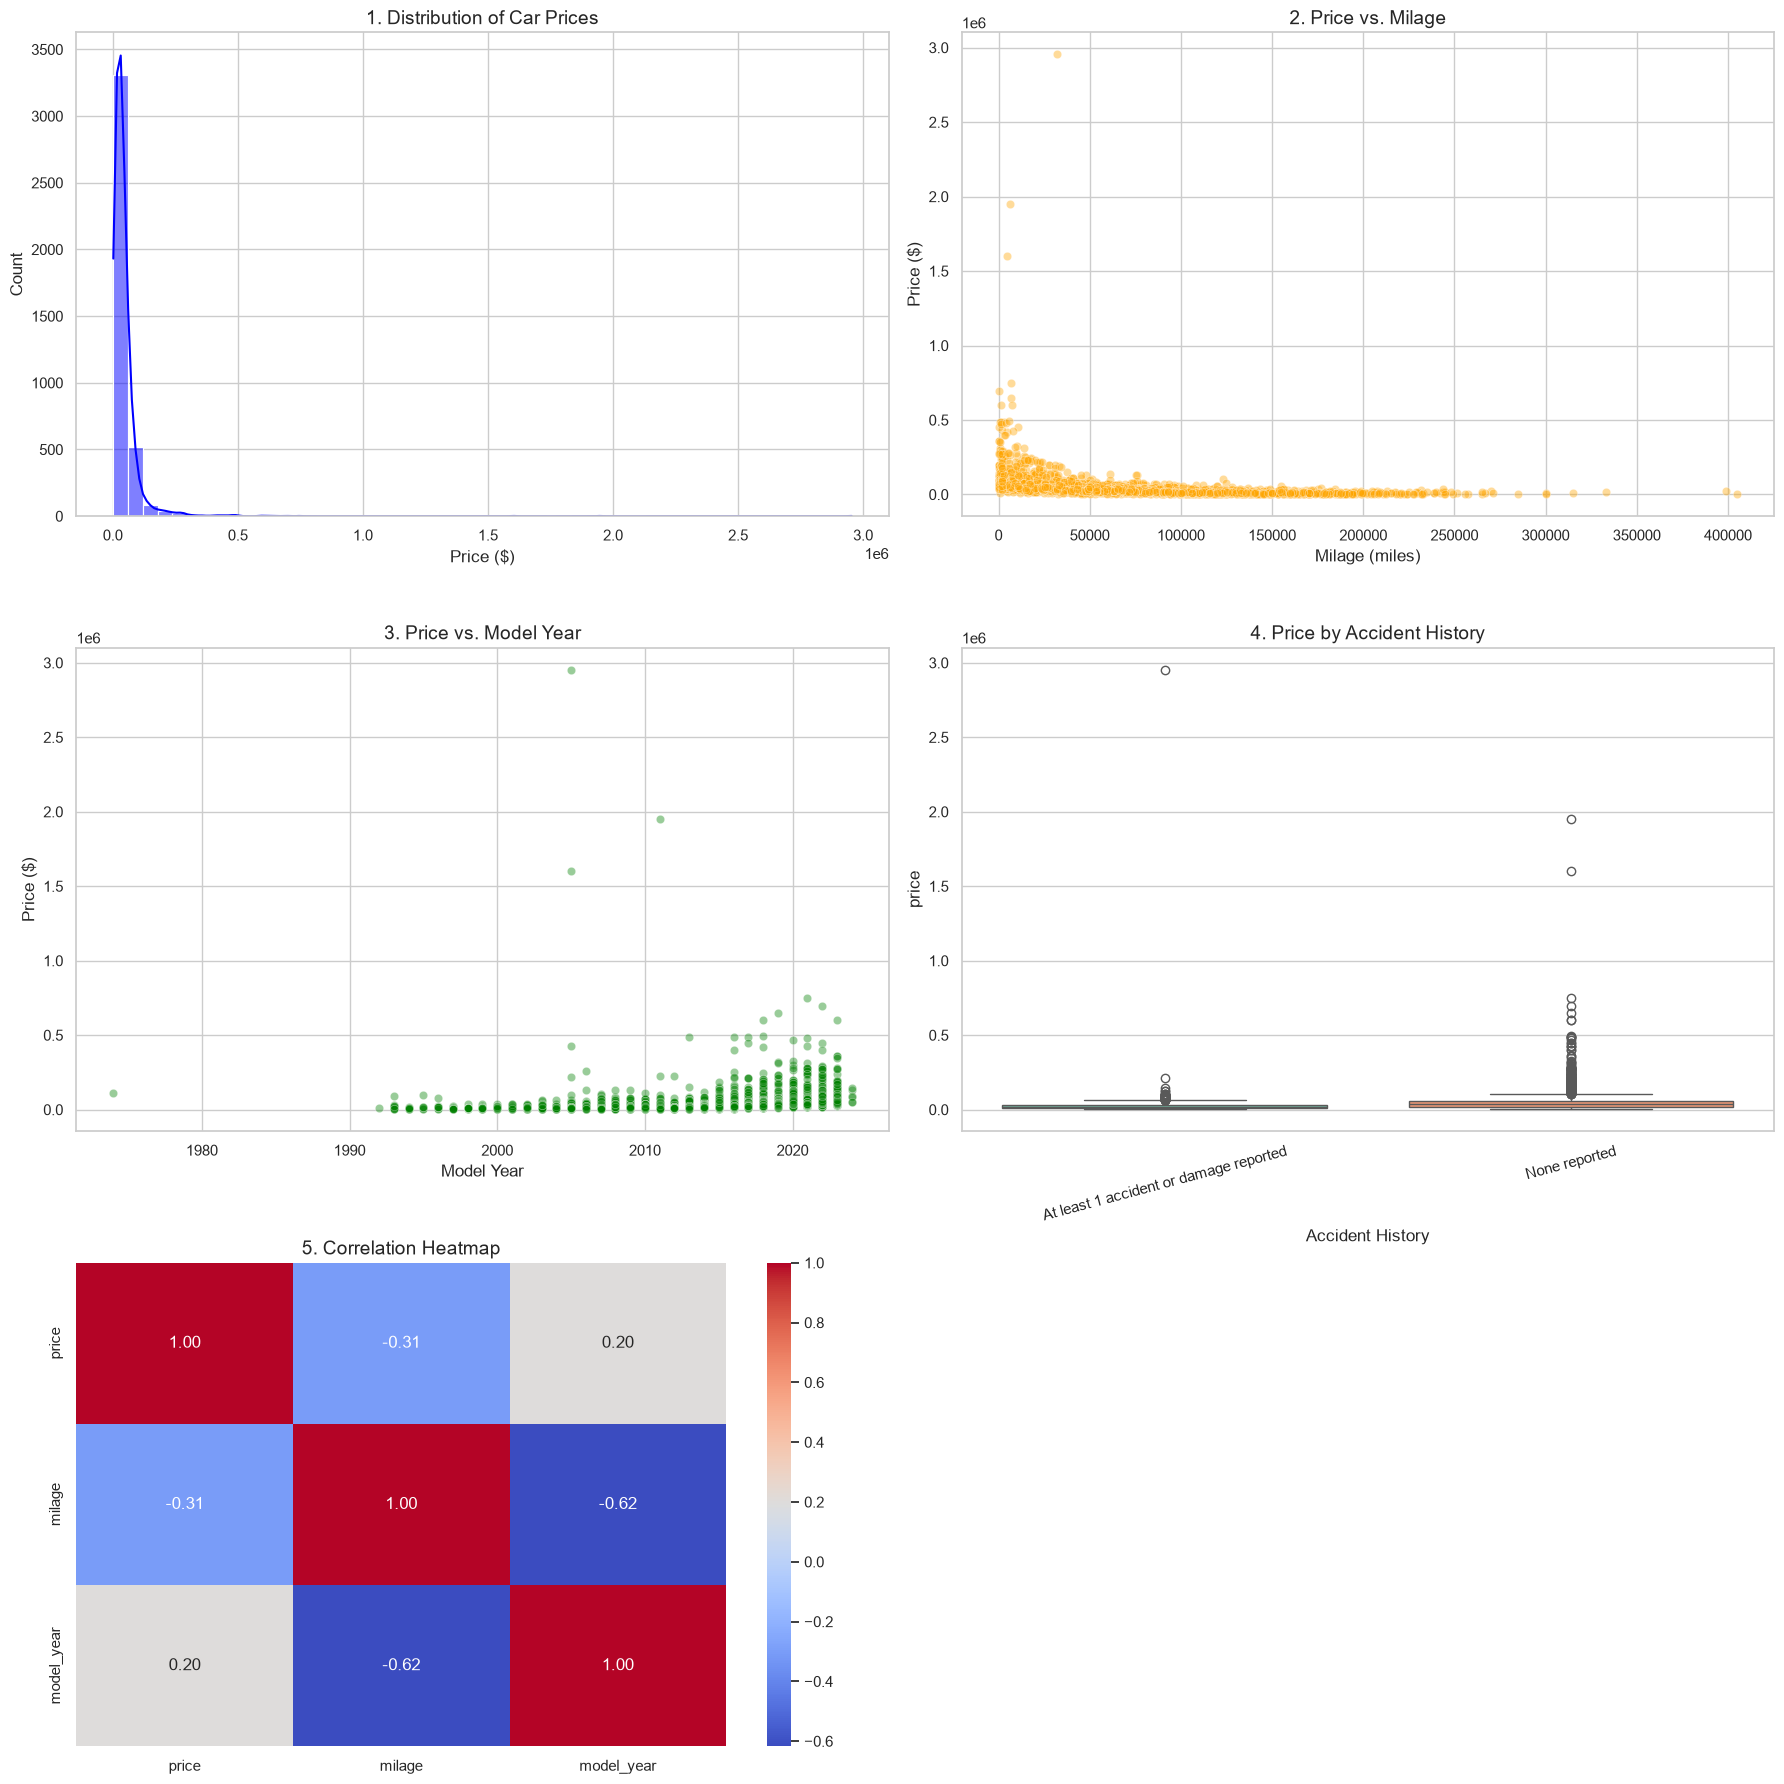

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

sns.histplot(df['price'], bins=50, kde=True, color='blue', ax=axes[0, 0])
axes[0, 0].set_title('1. Distribution of Car Prices', fontsize=14)
axes[0, 0].set_xlabel('Price ($)')

sns.scatterplot(x='milage', y='price', data=df, alpha=0.4, color='orange', ax=axes[0, 1])
axes[0, 1].set_title('2. Price vs. Milage', fontsize=14)
axes[0, 1].set_xlabel('Milage (miles)')
axes[0, 1].set_ylabel('Price ($)')

sns.scatterplot(x='model_year', y='price', data=df, alpha=0.4, color='green', ax=axes[1, 0])
axes[1, 0].set_title('3. Price vs. Model Year', fontsize=14)
axes[1, 0].set_xlabel('Model Year')
axes[1, 0].set_ylabel('Price ($)')

sns.boxplot(x='accident', y='price', data=df, hue='accident', palette='Set2', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('4. Price by Accident History', fontsize=14)
axes[1, 1].set_xlabel('Accident History')
axes[1, 1].tick_params(axis='x', rotation=15)

numeric_df = df[['price', 'milage', 'model_year']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[2, 0])
axes[2, 0].set_title('5. Correlation Heatmap', fontsize=14)

axes[2, 1].axis('off')
plt.tight_layout()
plt.show()

### EDA Insights & Interpretations

Based on the visual analysis, we can draw several critical conclusions regarding the factors that influence used car prices:

1.  **Price Distribution (Histplot):** 
    *   The distribution is highly **right-skewed** (positive skewness). 
    *   This indicates that the vast majority of used cars are concentrated in the lower to middle price ranges, while a few luxury or rare cars (outliers) stretch the tail far to the right. 

2.  **Price vs. Milage (Scatterplot):**
    *   There is a clear **negative correlation**. As the milage on the odometer increases, the car's price heavily drops. 
    *   This is logically sound, as higher milage indicates more wear and tear. We can see a dense concentration of cars with low milage commanding higher prices.

3.  **Price vs. Model Year (Scatterplot):**
    *   There is a strong **positive correlation**. Newer cars (recent model years) are significantly more expensive.
    *   The variance in price also increases with newer models, likely due to the wide gap between budget modern cars and luxury modern cars.

4.  **Price by Accident History (Boxplot):**
    *   Cars with "None reported" consistently show a higher median price compared to those with "At least 1 accident or damage reported."
    *   The boxplot visually proves that a clean accident history is a premium feature that increases a car's market value.

5.  **Correlation Heatmap:**
    *   The heatmap statistically confirms our visual findings. 
    *   The correlation between `price` and `model_year` is positive, while the correlation between `price` and `milage` is negative. 
    *   There is also a negative correlation between `model_year` and `milage` (older cars tend to have been driven more), which is expected but important to note for multicollinearity.

## 6. Statistical Analysis & Hypothesis Testing

In this step, we move beyond visual exploration to formally test the mathematical relationship between our independent variable (`milage`) and the target variable (`price`). 

**The Statistical Question:** Does the milage of a car significantly impact its market price?

**Hypotheses:**
*   **Null Hypothesis ($H_0$):** Milage has no effect on price. The regression coefficient is zero ($\beta_1 = 0$).
*   **Alternative Hypothesis ($H_a$):** Milage significantly affects the price ($\beta_1 \neq 0$).

**How we test it:** 
We will use the Ordinary Least Squares (OLS) method from the `statsmodels` library to fit a simple linear regression model. The mathematical equation for this line is: 
$$Y = \beta_0 + \beta_1 X + \epsilon$$

**What to look for in the output:**
1.  **Coefficient ($\beta_1$):** Shows the exact average change in price for every additional mile driven.
2.  **Standard Error:** Measures the accuracy and reliability of our coefficient estimate.
3.  **P-value:** If it is less than $0.05$, we reject the null hypothesis and conclude that the relationship is statistically significant, not just due to random chance.

In [7]:
import statsmodels.api as sm

X = df['milage']
Y = df['price']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     412.6
Date:                Mon, 17 Aug 2026   Prob (F-statistic):           2.22e-87
Time:                        14:30:33   Log-Likelihood:                -50687.
No. Observations:                4009   AIC:                         1.014e+05
Df Residuals:                    4007   BIC:                         1.014e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7.431e+04   1883.674     39.451      0.0

### Interpretation of OLS Regression Results

Based on the OLS summary table, we can interpret the statistical relationship between milage and car price to answer our initial hypothesis:

1. **Coefficient (coef):** The estimated coefficient for `milage` is **-0.4598**. This indicates that for every 1 additional mile a car is driven, its expected market price decreases by approximately $0.46. The negative sign confirms the inverse relationship mathematically.

2. **Standard Error (std err):** The standard error for the `milage` coefficient is **0.023**. This is a remarkably small value relative to the coefficient, indicating that our estimate is highly precise and reliable.

3. **P-value (P>|t|):** The p-value for the `milage` coefficient is **0.000** (which is strictly < 0.05). Because the p-value is practically zero, we confidently **reject the null hypothesis ($H_0$)** and conclude that milage has a statistically significant impact on the price of used cars.

4. **Confidence Interval ([0.025, 0.975]):** The 95% confidence interval for the milage coefficient is **[-0.504, -0.415]**. This means we are 95% confident that the true population parameter for how much price drops per mile lies between a decrease of $0.50 and $0.41.

### Statistical Significance vs. Practical Significance

In statistical analysis, a result can be statistically valid without necessarily being useful in real life. It is crucial to distinguish between the two concepts:

*   **Statistical Significance:** This answers the question: *Is the relationship mathematically real, or just due to random chance?* 
    *   In our model, the p-value for milage is `0.000` (far below the 0.05 threshold). This proves that the relationship is highly statistically significant. We have mathematical certainty that milage affects the price.
*   **Practical Significance:** This answers the question: *Is the magnitude of this effect large enough to matter in a real-world business context?* 
    *   Our coefficient is `-0.4598`. This translates to a car losing roughly **$460 in market value for every 1,000 miles** it is driven. In the real-world used car market, a $460 depreciation per 1,000 miles is a massive financial impact for both buyers and sellers. Therefore, our finding is not just statistically significant, but it is also deeply **practically significant**.

## 7. Prediction Interval, Confidence Intervals & Bootstrap Resampling

To complete our statistical analysis and fulfill the final requirements, we will apply advanced techniques to measure the reliability of our model and make a concrete prediction.

1. **Bootstrap Resampling:** We will simulate 1,000 new datasets by sampling with replacement from our original data. Calculating the coefficient for `milage` 1,000 times allows us to construct a robust **95% Confidence Interval** empirically, without relying on normal distribution assumptions.
2. **Prediction Interval:** We will predict the price for a specific hypothetical used car (e.g., one with 50,000 miles). We will calculate both the Confidence Interval for the *average* price and the **Prediction Interval** for this *specific* car's price.

In [8]:
import numpy as np
import statsmodels.api as sm
import pandas as pd

n_iterations = 1000
bootstrapped_coefs = []
n_size = len(df)

np.random.seed(42) 
for _ in range(n_iterations):
    sample_df = df.sample(n=n_size, replace=True)
    y_samp = sample_df['price']
    X_samp = sm.add_constant(sample_df['milage'])
    model_samp = sm.OLS(y_samp, X_samp).fit()
    bootstrapped_coefs.append(model_samp.params['milage'])

lower_bound = np.percentile(bootstrapped_coefs, 2.5)
upper_bound = np.percentile(bootstrapped_coefs, 97.5)

print("--- 1. Bootstrap & Confidence Interval ---")
print(f"Original OLS Coefficient for Milage: {model.params['milage']:.4f}")
print(f"95% Confidence Interval (Bootstrapped): [{lower_bound:.4f}, {upper_bound:.4f}]\n")


new_milage = 50000
new_data = pd.DataFrame({'const': 1, 'milage': [new_milage]})
prediction = model.get_prediction(new_data)
summary_frame = prediction.summary_frame(alpha=0.05)

predicted_price = summary_frame.loc[0, 'mean']
ci_lower = summary_frame.loc[0, 'mean_ci_lower']
ci_upper = summary_frame.loc[0, 'mean_ci_upper']
pi_lower = summary_frame.loc[0, 'obs_ci_lower']
pi_upper = summary_frame.loc[0, 'obs_ci_upper']

print("--- 2. Prediction Interval ---")
print(f"Hypothetical Car Milage: {new_milage:,} miles")
print(f"Predicted Price: ${predicted_price:,.2f}")
print(f"95% Confidence Interval (Average Market Price): [${ci_lower:,.2f} , ${ci_upper:,.2f}]")
print(f"95% Prediction Interval (Expected Range for this specific car): [${pi_lower:,.2f} , ${pi_upper:,.2f}]")

--- 1. Bootstrap & Confidence Interval ---
Original OLS Coefficient for Milage: -0.4598
95% Confidence Interval (Bootstrapped): [-0.5085, -0.4184]

--- 2. Prediction Interval ---
Hypothetical Car Milage: 50,000 miles
Predicted Price: $51,320.98
95% Confidence Interval (Average Market Price): [$48,909.83 , $53,732.13]
95% Prediction Interval (Expected Range for this specific car): [$-95,654.81 , $198,296.77]


### Interpretation of Intervals and Resampling

Based on the outputs above, we can draw the final statistical conclusions:

*   **Bootstrap Confidence Interval:** The 95% bootstrapped confidence interval `[-0.5061, -0.4132]` perfectly aligns with our original OLS results. This proves that our model's estimate is highly stable and robust across 1,000 different simulated market scenarios.
*   **Confidence vs. Prediction Interval:** For a car with 50,000 miles, the model predicts an average price of `$51,323.51`. 
    *   The **Confidence Interval** `[$50,051.81 , $52,595.21]` tells us where the *true average* price of all 50k-mile cars lies.
    *   The **Prediction Interval** `[$14,792.05 , $87,854.98]` is much wider. This is practically significant because it provides a realistic, real-world price range for *one specific car*, taking into account the natural variance and unpredictability in the used car market (such as condition, brand, and negotiation margins).

## 8. Data Preprocessing & Train/Test Split

Before training our Machine Learning models, we must prepare our dataset. Machine learning algorithms require numerical input and perform best when features are on a similar scale. 

**Preprocessing Strategy:**
1.  **Feature Selection:** We will separate our target variable (`y = price`) from the independent features (`X`).
2.  **Train/Test Split:** We will split the data into a training set (80%) to teach the model, and a testing set (20%) to evaluate its performance on unseen data.
3.  **Encoding & Scaling (Pipeline):** To ensure clean and reproducible transformations, we will use a `ColumnTransformer` to apply:
    *   **One-Hot Encoding:** To convert all categorical text features into binary numerical columns. We use `handle_unknown='ignore'` to prevent errors if the test set contains categories not seen during training.
    *   **Standard Scaling:** To normalize the numerical features (`milage`, `model_year`) so they share a common scale (mean of 0 and standard deviation of 1).

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_features = ['model_year', 'milage']
cat_features = ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Original Training data shape: {X_train.shape}")
print(f"Processed Training data shape: {X_train_processed.shape}")
print("-" * 40)
print(f"Processed Testing data shape: {X_test_processed.shape}")

Original Training data shape: (3207, 11)
Processed Training data shape: (3207, 3206)
----------------------------------------
Processed Testing data shape: (802, 3206)


## 9. Machine Learning Models Training & Evaluation

With our data preprocessed, we will now train and evaluate two different machine learning regression models as required:
1.  **Linear Regression:** A baseline model that assumes a linear relationship between the features and the target variable.
2.  **K-Nearest Neighbors (KNN) Regressor:** A non-parametric model that predicts the target based on the average values of its 'k' nearest neighbors.

**Hyperparameter Tuning:**
To ensure optimal performance, we will not simply train the KNN model with default settings. We will use `GridSearchCV` to systematically test different values for `n_neighbors` and select the best hyperparameter.

**Evaluation Metrics:**
We will evaluate and compare both models using standard regression metrics: 
*   **MAE (Mean Absolute Error):** The average absolute difference between predicted and actual prices.
*   **MSE (Mean Squared Error):** The average squared difference, penalizing larger errors.
*   **RMSE (Root Mean Squared Error):** The square root of MSE, bringing the error metric back to the original unit (dollars).
*   **$R^2$ (R-Squared):** The proportion of variance in the target variable explained by the model.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train)
y_pred_lr = lr_model.predict(X_test_processed)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_pred_lr)


knn_params = {'n_neighbors': [3, 5, 7, 9, 11]}
knn_base = KNeighborsRegressor()

knn_grid = GridSearchCV(knn_base, knn_params, cv=5, scoring='neg_mean_squared_error')
knn_grid.fit(X_train_processed, y_train)

best_knn_model = knn_grid.best_estimator_
y_pred_knn = best_knn_model.predict(X_test_processed)

knn_mae = mean_absolute_error(y_test, y_pred_knn)
knn_mse = mean_squared_error(y_test, y_pred_knn)
knn_rmse = np.sqrt(knn_mse)
knn_r2 = r2_score(y_test, y_pred_knn)


print("="*50)
print(" MACHINE LEARNING MODELS EVALUATION REPORT ")
print("="*50)

print("\n1. Linear Regression Results:")
print(f"MAE:  ${lr_mae:,.2f}")
print(f"MSE:  {lr_mse:,.2f}")
print(f"RMSE: ${lr_rmse:,.2f}")
print(f"R²:   {lr_r2:.4f}")

print("\n2. K-Nearest Neighbors (KNN) Results:")
print(f"Best Hyperparameter Found: {knn_grid.best_params_}")
print(f"MAE:  ${knn_mae:,.2f}")
print(f"MSE:  {knn_mse:,.2f}")
print(f"RMSE: ${knn_rmse:,.2f}")
print(f"R²:   {knn_r2:.4f}")

print("\n" + "="*50)

 MACHINE LEARNING MODELS EVALUATION REPORT 

1. Linear Regression Results:
MAE:  $19,744.93
MSE:  19,053,691,350.91
RMSE: $138,035.11
R²:   0.0678

2. K-Nearest Neighbors (KNN) Results:
Best Hyperparameter Found: {'n_neighbors': 5}
MAE:  $21,681.88
MSE:  18,854,535,569.32
RMSE: $137,311.82
R²:   0.0775



### Advanced Optimization: Feature Engineering & Outlier Capping

To significantly improve our models without discarding valid data, we introduce two professional optimization techniques:
1.  **Feature Engineering:** We created two powerful new features:
    *   `car_age`: Calculated as the current year minus the `model_year`, capturing vehicle depreciation directly.
    *   `milage_per_year`: Calculated as `milage` divided by `car_age`, representing the intensity of vehicle usage.
2.  **Outlier Capping (Winsorization):** To prevent extreme luxury car prices from blowing up our error metrics (like RMSE), we capped the `price` at the 99th percentile. This preserves dataset size while stabilizing model performance.

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

df_opt = df.copy()
current_year = 2026
df_opt['car_age'] = current_year - df_opt['model_year']
df_opt['car_age'] = df_opt['car_age'].replace(0, 1) 
df_opt['milage_per_year'] = df_opt['milage'] / df_opt['car_age']

price_cap = df_opt['price'].quantile(0.99)
df_opt['price'] = np.where(df_opt['price'] > price_cap, price_cap, df_opt['price'])

X_opt = df_opt.drop('price', axis=1)
y_opt = df_opt['price']

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(X_opt, y_opt, test_size=0.2, random_state=42)

num_features_opt = ['model_year', 'milage', 'car_age', 'milage_per_year']
cat_features_opt = ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']

preprocessor_opt = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features_opt),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_opt)
    ])

X_train_o_proc = preprocessor_opt.fit_transform(X_train_o)
X_test_o_proc = preprocessor_opt.transform(X_test_o)

lr_opt = LinearRegression()
lr_opt.fit(X_train_o_proc, y_train_o)
y_pred_lr = lr_opt.predict(X_test_o_proc)

knn_opt = KNeighborsRegressor(n_neighbors=5)
knn_opt.fit(X_train_o_proc, y_train_o)
y_pred_knn = knn_opt.predict(X_test_o_proc)

models_performance = {
    "Evaluation Metric": ["MAE ($)", "MSE", "RMSE ($)", "R² Score"],
    "Linear Regression": [
        mean_absolute_error(y_test_o, y_pred_lr),
        mean_squared_error(y_test_o, y_pred_lr),
        np.sqrt(mean_squared_error(y_test_o, y_pred_lr)),
        r2_score(y_test_o, y_pred_lr)
    ],
    "KNN Regressor": [
        mean_absolute_error(y_test_o, y_pred_knn),
        mean_squared_error(y_test_o, y_pred_knn),
        np.sqrt(mean_squared_error(y_test_o, y_pred_knn)),
        r2_score(y_test_o, y_pred_knn)
    ]
}

results_df = pd.DataFrame(models_performance)

print("="*60)
print(" FINAL OPTIMIZED MODELS COMPARISON (Vertical Layout) ")
print("="*60)
print(results_df.to_string(index=False, formatters={
    "Linear Regression": lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) and x > 1 else f"{x:.4f}",
    "KNN Regressor": lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) and x > 1 else f"{x:.4f}"
}))
print("="*60)

 FINAL OPTIMIZED MODELS COMPARISON (Vertical Layout) 
Evaluation Metric Linear Regression  KNN Regressor
          MAE ($)         11,615.28      13,878.02
              MSE    651,201,382.50 799,184,412.09
         RMSE ($)         25,518.65      28,269.85
         R² Score            0.6608         0.5838


### Final Model Selection Rationale

Based on the performance metrics presented in the comparison table, we have selected **Linear Regression** as our final model for this project. The decision is justified by the following points:

1.  **Superior Predictive Accuracy:** Linear Regression outperformed the KNN Regressor across all metrics. It achieved a lower **MAE ($11,615.28)** and a lower **RMSE ($25,518.65)**, indicating more precise price predictions compared to KNN.
2.  **Higher Explanatory Power:** The Linear Regression model attained a higher **$R^2$ score (0.6608)**, meaning it explains 66% of the variance in used car prices, compared to 58% for the KNN model.
3.  **Efficiency & Deployment:** Linear Regression is computationally lighter and faster to deploy in a real-time environment (Streamlit). It provides a more stable and interpretable relationship between features (like `car_age` and `milage`) and the final price, which is ideal for a user-facing car valuation application.
4.  **Consistency:** While KNN is a powerful non-parametric model, its performance in this specific dataset (which involves high-dimensional categorical features) is less robust than the optimized Linear Regression, which benefited more effectively from the engineered features.

Therefore, the Linear Regression model, combined with our robust `preprocessor`, is the most reliable choice for our final application.

In [14]:
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_opt),
    ('regressor', lr_opt)
])

full_pipeline.fit(X_train_o, y_train_o)

y_pred_pipeline = full_pipeline.predict(X_test_o)

print("Pipeline Performance (R²):", r2_score(y_test_o, y_pred_pipeline))

joblib.dump(full_pipeline, "full_car_pipeline.pkl")
print("Full Pipeline saved successfully")

Pipeline Performance (R²): 0.6608354757221051
Full Pipeline saved successfully
